# Customer Segmentation Analysis

### Oasis Infobyte Data Analytics Internship

**Name:** Natasha Bhartiya

**Track:** Data Analytics

**Task:** Level 1 - Task 2

**Tools Used:** Python, Pandas, Matplotlib, Seaborn, Scikit-learn

**Dataset:** Mall Customers Dataset

## Import Libraries

In [280]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Load Dataset

In [281]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Dataset Information

In [282]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


## Dataset Shape

In [283]:
print(df.shape)

(200, 5)


## Display Column Names

In [284]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

## Missing Values

In [285]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Statistical Summary

In [286]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Check Duplicate Records

In [287]:
df.duplicated().sum()

np.int64(0)

## Dataset Preview

In [288]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


## Gender Distribution

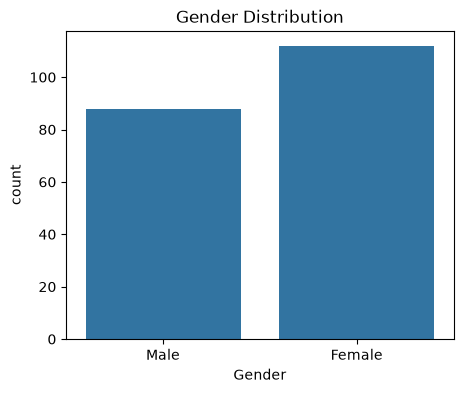

In [289]:
plt.figure(figsize=(5,4))
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.show()

## Age Distribution

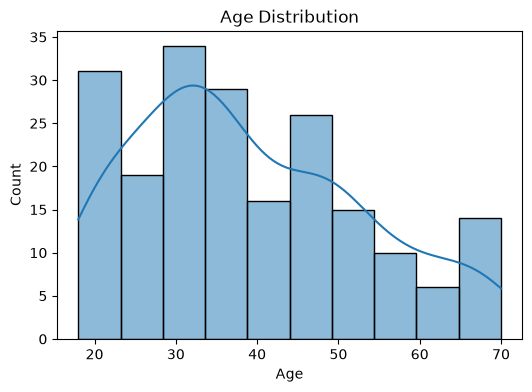

In [290]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=10, kde=True)

plt.title("Age Distribution")
plt.show()

## Annual Income Distribution

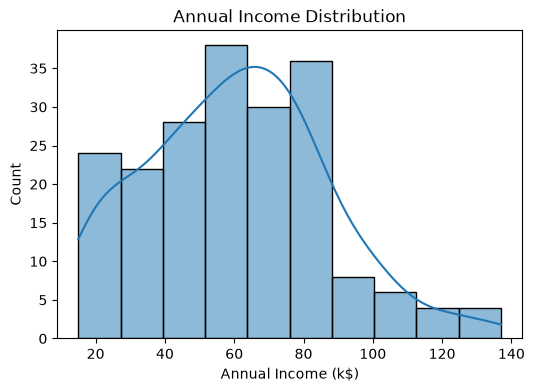

In [291]:
plt.figure(figsize=(6,4))
sns.histplot(df["Annual Income (k$)"], bins=10, kde=True)

plt.title("Annual Income Distribution")
plt.show()

## Spending Score Distribution

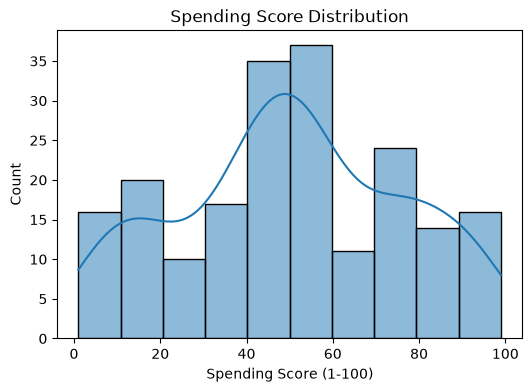

In [292]:
plt.figure(figsize=(6,4))
sns.histplot(df["Spending Score (1-100)"], bins=10, kde=True)

plt.title("Spending Score Distribution")
plt.show()

## Correlation Heatmap

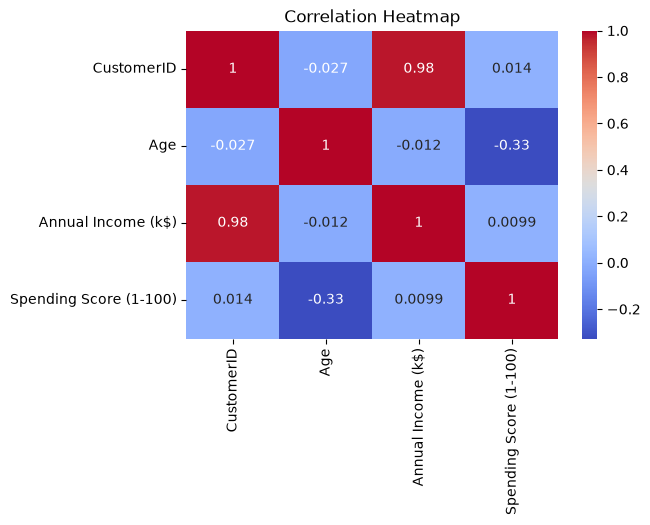

In [293]:
plt.figure(figsize=(6,4))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

## Feature Selection

In [294]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Feature Scaling

In [295]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Elbow Method

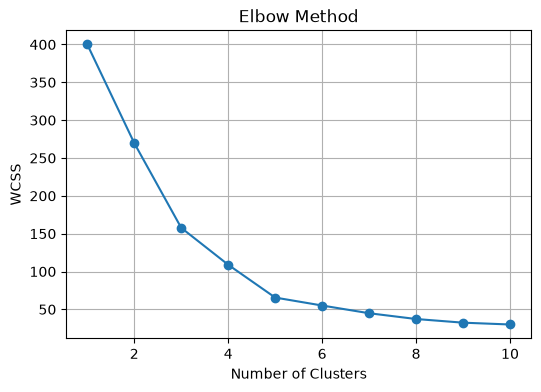

In [296]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

## K-Means Clustering

In [297]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Customer Segmentation Visualization

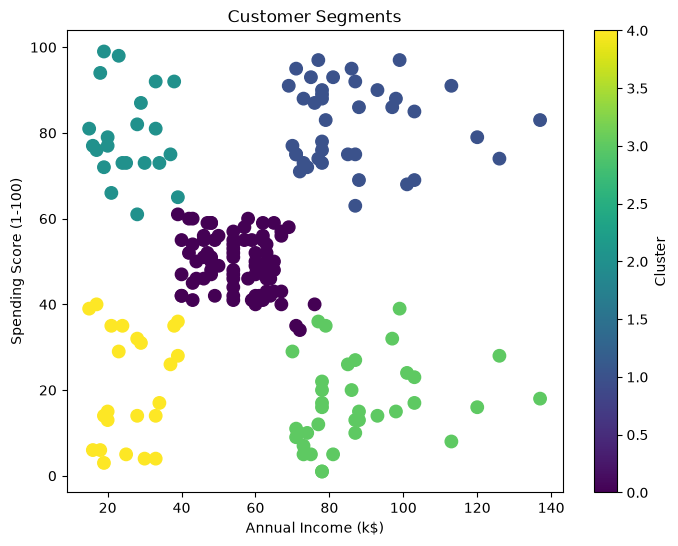

In [298]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=80
)

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.colorbar(label="Cluster")
plt.show()

## Conclusion

This project used K-Means Clustering to divide customers into different groups based on their annual income and spending score. Customer segmentation helps businesses understand customer behavior and create better marketing strategies.

## Cluster Summary

In [299]:
df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


## Number of Customers in Each Cluster

In [300]:
df["Cluster"].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

## Insights

- Customers are divided into 5 different clusters.
- Each cluster has different spending behaviour.
- High income customers with high spending are premium customers.
- Low income customers with low spending require different marketing strategies.
- Customer segmentation helps businesses improve sales and customer satisfaction.

# Final Conclusion
This project successfully performed Customer Segmentation using the K-Means Clustering algorithm. The analysis identified different customer groups based on Annual Income and Spending Score. These insights can help businesses create personalized marketing campaigns and improve customer engagement.